In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
##for dirname, _, filenames in os.walk('/kaggle/input'):
    # for filename in filenames:
    #     print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

## Hierarchical VAE Code For MNIST Dataset

In [3]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, Model
import os

# Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)

# --- Data Processing ---
class DataProcessor:
    def __init__(self, batch_size=128):
        self.batch_size = batch_size
        self.x_train = None
        self.x_test = None

    def load_and_preprocess(self):
        # Load MNIST dataset
        (x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()
        
        # Normalize and reshape
        self.x_train = x_train.astype('float32') / 255.0
        self.x_test = x_test.astype('float32') / 255.0
        self.x_train = self.x_train.reshape(-1, 28, 28, 1)
        self.x_test = self.x_test.reshape(-1, 28, 28, 1)

    def get_train_dataset(self):
        # Create a TensorFlow dataset for training
        dataset = tf.data.Dataset.from_tensor_slices(self.x_train)
        dataset = dataset.shuffle(60000).batch(self.batch_size)
        return dataset

    def get_test_data(self):
        return self.x_test

# --- HVAE Model Definition ---
class HVAE(Model):
    def __init__(self, latent_dim1=16, latent_dim2=2, beta=0.5):
        super(HVAE, self).__init__()
        self.latent_dim1 = latent_dim1  # Dimension for z1 (lower-level latent)
        self.latent_dim2 = latent_dim2  # Dimension for z2 (higher-level latent)
        self.beta = beta  # Weight for KL divergence terms

        # Bottom-up encoder for z1
        self.encoder_z1 = tf.keras.Sequential([
            layers.InputLayer(input_shape=(28, 28, 1)),
            layers.Conv2D(64, 3, strides=2, padding='same', activation='relu'),
            layers.Conv2D(128, 3, strides=2, padding='same', activation='relu'),
            layers.Conv2D(256, 3, strides=1, padding='same', activation='relu'),
            layers.Flatten(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(latent_dim1 * 2)  # Outputs mean and log-variance for z1
        ])

        # Bottom-up encoder for z2 conditioned on z1
        self.encoder_z2 = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim1,)),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(64, activation='relu'),
            layers.Dense(latent_dim2 * 2)  # Outputs mean and log-variance for z2
        ])

        # Top-down decoder for z1 conditioned on z2
        self.decoder_z1 = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim2,)),
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(64, activation='relu'),
            layers.Dense(latent_dim1 * 2)  # Outputs mean and log-variance for z1
        ])

        # Top-down decoder for x conditioned on z1
        self.decoder_x = tf.keras.Sequential([
            layers.InputLayer(input_shape=(latent_dim1,)),
            layers.Dense(7 * 7 * 128, activation='relu'),
            layers.Reshape((7, 7, 128)),
            layers.Conv2DTranspose(64, 3, strides=2, padding='same', activation='relu'),
            layers.Conv2DTranspose(32, 3, strides=2, padding='same', activation='relu'),
            layers.Conv2DTranspose(1, 3, strides=1, padding='same', activation='sigmoid')
        ])

    def encode(self, x):
        # Encode x to z1 parameters
        z1_params = self.encoder_z1(x)
        z1_mean, z1_logvar = tf.split(z1_params, num_or_size_splits=2, axis=1)
        z1_logvar = tf.clip_by_value(z1_logvar, -10.0, 10.0)  # Clip log-variance
        z1 = self._reparameterize(z1_mean, z1_logvar)

        # Encode z1 to z2 parameters
        z2_params = self.encoder_z2(z1)
        z2_mean, z2_logvar = tf.split(z2_params, num_or_size_splits=2, axis=1)
        z2_logvar = tf.clip_by_value(z2_logvar, -10.0, 10.0)  # Clip log-variance
        z2 = self._reparameterize(z2_mean, z2_logvar)
        return z1_mean, z1_logvar, z1, z2_mean, z2_logvar, z2

    def decode(self, z2):
        # Decode z2 to z1 parameters
        z1_params = self.decoder_z1(z2)
        z1_mean, z1_logvar = tf.split(z1_params, num_or_size_splits=2, axis=1)
        z1_logvar = tf.clip_by_value(z1_logvar, -10.0, 10.0)  # Clip log-variance
        z1 = self._reparameterize(z1_mean, z1_logvar)

        # Decode z1 to x
        x_recon = self.decoder_x(z1)
        return x_recon, z1_mean, z1_logvar

    def _reparameterize(self, mean, logvar):
        # Reparameterization trick for sampling
        eps = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * logvar) * eps

    def call(self, x):
        z1_mean, z1_logvar, z1, z2_mean, z2_logvar, z2 = self.encode(x)
        x_recon, z1_mean_dec, z1_logvar_dec = self.decode(z2)
        return x_recon, z1_mean, z1_logvar, z2_mean, z2_logvar, z1_mean_dec, z1_logvar_dec

    def compute_loss(self, x):
        # Compute the loss for the HVAE
        x_recon, z1_mean, z1_logvar, z2_mean, z2_logvar, z1_mean_dec, z1_logvar_dec = self(x)

        # Ensure x_recon is in [0, 1] for binary cross-entropy
        x_recon = tf.clip_by_value(x_recon, 1e-7, 1 - 1e-7)

        # Reconstruction loss (binary cross-entropy)
        recon_loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(x, x_recon) * 28 * 28
        )

        # KL divergence for z2 (prior is N(0,1)) with numerical stability
        kl_z2 = -0.5 * tf.reduce_mean(
            1 + z2_logvar - tf.square(z2_mean) - tf.exp(z2_logvar + 1e-10)
        )

        # KL divergence for z1 (prior from decoder_z1) with numerical stability
        kl_z1 = tfp.distributions.kl_divergence(
            tfp.distributions.Normal(z1_mean, tf.exp(0.5 * z1_logvar) + 1e-10),
            tfp.distributions.Normal(z1_mean_dec, tf.exp(0.5 * z1_logvar_dec) + 1e-10)
        )
        kl_z1 = tf.reduce_mean(kl_z1)

        # Total loss with beta weighting
        total_loss = recon_loss + self.beta * (kl_z2 + kl_z1)
        return total_loss, recon_loss, kl_z2, kl_z1

    def compute_mse(self, x, x_recon):
        # Compute Mean Squared Error as a proxy for accuracy
        mse = tf.keras.losses.MeanSquaredError()
        return mse(x, x_recon)

# --- Training Logic ---
class HVAETrainer:
    def __init__(self, model, dataset, epochs=50):
        self.model = model
        self.dataset = dataset
        self.epochs = epochs
        self.optimizer = tf.keras.optimizers.Adam(
            learning_rate=tf.keras.optimizers.schedules.ExponentialDecay(
                initial_learning_rate=1e-4,  # Reduced initial learning rate
                decay_steps=1000,
                decay_rate=0.9
            )
        )
        self.metrics_history = {
            'total_loss': [],
            'recon_loss': [],
            'kl_z2': [],
            'kl_z1': [],
            'mse': []
        }

    @tf.function
    def train_step(self, x):
        # Single training step with gradient clipping
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_z2, kl_z1 = self.model.compute_loss(x)
        gradients = tape.gradient(total_loss, self.model.trainable_variables)
        gradients = [tf.clip_by_norm(g, 1.0) for g in gradients]
        self.optimizer.apply_gradients(zip(gradients, self.model.trainable_variables))
        return total_loss, recon_loss, kl_z2, kl_z1

    def train(self):
        # Main training loop
        for epoch in range(self.epochs):
            print(f"Training Epoch {epoch + 1}/{self.epochs}")
            total_loss_epoch = 0
            recon_loss_epoch = 0
            kl_z2_epoch = 0
            kl_z1_epoch = 0
            mse_epoch = 0
            num_batches = 0

            for x_batch in self.dataset:
                total_loss, recon_loss, kl_z2, kl_z1 = self.train_step(x_batch)
                x_recon, _, _, _, _, _, _ = self.model(x_batch)
                mse = self.model.compute_mse(x_batch, x_recon)

                # Check for nan values
                if tf.math.is_nan(total_loss):
                    print("Warning: NaN detected in loss computation")
                    return self.metrics_history

                total_loss_epoch += total_loss
                recon_loss_epoch += recon_loss
                kl_z2_epoch += kl_z2
                kl_z1_epoch += kl_z1
                mse_epoch += mse
                num_batches += 1

            # Average metrics for the epoch
            total_loss_epoch /= num_batches
            recon_loss_epoch /= num_batches
            kl_z2_epoch /= num_batches
            kl_z1_epoch /= num_batches
            mse_epoch /= num_batches

            self.metrics_history['total_loss'].append(float(total_loss_epoch))
            self.metrics_history['recon_loss'].append(float(recon_loss_epoch))
            self.metrics_history['kl_z2'].append(float(kl_z2_epoch))
            self.metrics_history['kl_z1'].append(float(kl_z1_epoch))
            self.metrics_history['mse'].append(float(mse_epoch))

            print(f"Total Loss: {total_loss_epoch:.4f}, Recon Loss: {recon_loss_epoch:.4f}, "
                  f"KL z2: {kl_z2_epoch:.4f}, KL z1: {kl_z1_epoch:.4f}, MSE: {mse_epoch:.4f}")

        return self.metrics_history

# --- Visualization and Plotting ---
class HVAEVisualizer:
    def __init__(self, output_dir="results"):
        self.output_dir = output_dir
        if not os.path.exists(self.output_dir):
            os.makedirs(self.output_dir)

    def plot_latent_space(self, model, x_test, num_samples=1000):
        # Visualize the 2D latent space (z2)
        z1_mean, z1_logvar, z1, z2_mean, z2_logvar, z2 = model.encode(x_test[:num_samples])
        if model.latent_dim2 == 2:
            plt.figure(figsize=(8, 6))
            plt.scatter(z2[:, 0], z2[:, 1], s=5, alpha=0.5)
            plt.title("Latent Space (z2) Visualization")
            plt.xlabel("z2 Dim 1")
            plt.ylabel("z2 Dim 2")
            plt.grid(True)
            plt.savefig(os.path.join(self.output_dir, "latent_space_z2.png"))
            plt.close()

    def plot_metrics(self, metrics_history):
        # Plot all metrics over epochs
        plt.figure(figsize=(10, 6))
        plt.plot(metrics_history['total_loss'], label='Total Loss')
        plt.plot(metrics_history['recon_loss'], label='Reconstruction Loss')
        plt.plot(metrics_history['kl_z2'], label='KL Divergence (z2)')
        plt.plot(metrics_history['kl_z1'], label='KL Divergence (z1)')
        plt.plot(metrics_history['mse'], label='MSE')
        plt.title("Training Metrics Over Epochs")
        plt.xlabel("Epoch")
        plt.ylabel("Value")
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(self.output_dir, "metrics_plot.png"))
        plt.close()

    def save_reconstructed_images(self, model, x_test, num_samples=20):
        # Save original and reconstructed images
        x_recon, _, _, _, _, _, _ = model(x_test[:num_samples])
        plt.figure(figsize=(20, 8))
        for i in range(num_samples):
            # Original
            plt.subplot(4, 10, i + 1)
            plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title("Original")
            # Reconstructed
            plt.subplot(4, 10, i + 21)
            plt.imshow(x_recon[i].numpy().reshape(28, 28), cmap='gray')
            plt.axis('off')
            if i == 0:
                plt.title("Reconstructed")
        plt.savefig(os.path.join(self.output_dir, "reconstructed_images.png"))
        plt.close()

# --- Main Execution ---
def run_hvae_pipeline():
    # Step 1: Load and preprocess data
    data_handler = DataProcessor(batch_size=128)
    data_handler.load_and_preprocess()
    train_dataset = data_handler.get_train_dataset()
    test_data = data_handler.get_test_data()

    # Step 2: Initialize the HVAE model
    hvae_model = HVAE(latent_dim1=16, latent_dim2=2, beta=0.5)

    # Step 3: Print model summary
    print("\nHVAE Model Summary:")
    print("Encoder z1:")
    hvae_model.encoder_z1.summary()
    print("\nEncoder z2:")
    hvae_model.encoder_z2.summary()
    print("\nDecoder z1:")
    hvae_model.decoder_z1.summary()
    print("\nDecoder x:")
    hvae_model.decoder_x.summary()

    # Step 4: Train the model
    trainer = HVAETrainer(model=hvae_model, dataset=train_dataset, epochs=50)
    metrics_history = trainer.train()

    # Step 5: Visualize results
    visualizer = HVAEVisualizer(output_dir="results")
    visualizer.plot_latent_space(hvae_model, test_data)
    visualizer.plot_metrics(metrics_history)
    visualizer.save_reconstructed_images(hvae_model, test_data)

if __name__ == "__main__":
    run_hvae_pipeline()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/input_layer.py:26: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(



HVAE Model Summary:
Encoder z1:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 14, 14, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 7, 7, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 7, 7, 256)           │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 12544)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │       3,211,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           8,224 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 6272)                │         106,624 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 7, 7, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 14, 14, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 28, 28, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 28, 28, 1)           │             289 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 199,169 (778.00 KB)

 Trainable params: 199,169 (778.00 KB)

 Non-trainable params: 0 (0.00 B)

Training Epoch 1/50
Total Loss: 300.8835, Recon Loss: 268.3236, KL z2: 7.8001, KL z1: 57.3201, MSE: 0.0938
Training Epoch 2/50
Total Loss: 194.2980, Recon Loss: 192.3811, KL z2: 2.9778, KL z1: 0.8561, MSE: 0.0622
Training Epoch 3/50
Total Loss: 189.4307, Recon Loss: 187.4833, KL z2: 2.9524, KL z1: 0.9428, MSE: 0.0601
Training Epoch 4/50
Total Loss: 177.5170, Recon Loss: 174.6927, KL z2: 4.0884, KL z1: 1.5606, MSE: 0.0550
Training Epoch 5/50
Total Loss: 169.8383, Recon Loss: 166.8801, KL z2: 4.3354, KL z1: 1.5811, MSE: 0.0517
Training Epoch 6/50
Total Loss: 166.1857, Recon Loss: 163.1992, KL z2: 4.3435, KL z1: 1.6293, MSE: 0.0501
Training Epoch 7/50
Total Loss: 163.4847, Recon Loss: 160.4842, KL z2: 4.3090, KL z1: 1.6920, MSE: 0.0488
Training Epoch 8/50
Total Loss: 161.2129, Recon Loss: 158.2112, KL z2: 4.2546, KL z1: 1.7488, MSE: 0.0478
Training Epoch 9/50
Total Loss: 159.2143, Recon Loss: 156.2029, KL z2: 4.2251, KL z1: 1.7980, MSE: 0.0468
Training Epoch 10/50
Total Loss: 157.3110, Re

In [4]:
# encoder, decoder = train_model(epochs=10)
# decoder.save("hierarchical_vae_decoder.h5")
!zip -r results.zip /kaggle/working/results > /dev/null
from IPython.display import FileLink
FileLink(r'results.zip')

/kaggle/working/results.zip

## Hierarchical VAE Code For UCMereced Dataset

Train samples: 1470
Validation samples: 420
Test samples: 210
Using device: cuda
Epoch 1/50, Train Loss: 30879.4315
         Test Loss: 25582.9936
Epoch 2/50, Train Loss: 25277.7223
         Test Loss: 23915.0044
Epoch 3/50, Train Loss: 23411.2904
         Test Loss: 22538.7585
Epoch 4/50, Train Loss: 22476.0776
         Test Loss: 21731.5566
Epoch 5/50, Train Loss: 21764.9730
         Test Loss: 21547.1369
Epoch 6/50, Train Loss: 21437.6563
         Test Loss: 21033.1823
Epoch 7/50, Train Loss: 20972.9209
         Test Loss: 20823.0647
Epoch 8/50, Train Loss: 20745.6684
         Test Loss: 20612.7571
Epoch 9/50, Train Loss: 20117.5377
         Test Loss: 20475.9911
Epoch 10/50, Train Loss: 20259.8556
         Test Loss: 20173.6362
Epoch 11/50, Train Loss: 19476.3849
         Test Loss: 20337.3861
Epoch 12/50, Train Loss: 19462.1008
         Test Loss: 20231.5537
Epoch 13/50, Train Loss: 19150.2849
         Test Loss: 19937.2805
Epoch 14/50, Train Loss: 18774.4249
         Test Loss: 2

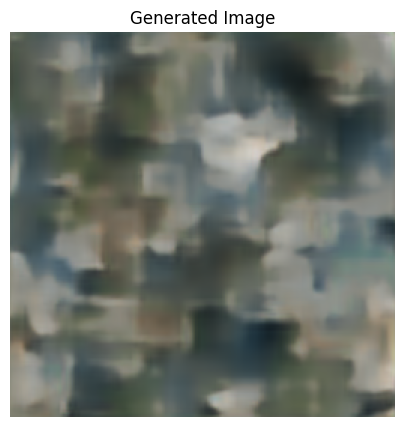

In [11]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ================================================================================
# Dataset Paths and Transforms (with image conversion and resizing)
# ================================================================================
base_path = '/kaggle/input/assignment5-dataset/Dataset'
train_path = os.path.join(base_path, 'train')
val_path   = os.path.join(base_path, 'val')
test_path  = os.path.join(base_path, 'test')

transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")),  # ensure 3 channels
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset   = datasets.ImageFolder(val_path, transform=transform)
test_dataset  = datasets.ImageFolder(test_path, transform=transform)

batch_size = 16
# Use num_workers=0 for debugging; later, try increasing for speed.
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print('Train samples:', len(train_dataset))
print('Validation samples:', len(val_dataset))
print('Test samples:', len(test_dataset))


# ================================================================================
# Hierarchical VAE Model Definition with Modified Decoder
# ================================================================================

def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

# Encoder remains unchanged:
class HVAEEncoder(nn.Module):
    def __init__(self, latent_dim1=64, latent_dim2=32):
        super(HVAEEncoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),    # 256 -> 128
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),   # 128 -> 64
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),  # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1),  # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1),  # 16 -> 8
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_size = 512 * 8 * 8

        self.fc_mu2 = nn.Linear(self.fc_size, latent_dim2)
        self.fc_logvar2 = nn.Linear(self.fc_size, latent_dim2)

        self.fc_mu1 = nn.Linear(self.fc_size + latent_dim2, latent_dim1)
        self.fc_logvar1 = nn.Linear(self.fc_size + latent_dim2, latent_dim1)

    def forward(self, x):
        h = self.conv(x)
        h_flat = self.flatten(h)
        mu2 = self.fc_mu2(h_flat)
        logvar2 = self.fc_logvar2(h_flat)
        z2 = reparameterize(mu2, logvar2)

        h_comb = torch.cat([h_flat, z2], dim=1)
        mu1 = self.fc_mu1(h_comb)
        logvar1 = self.fc_logvar1(h_comb)
        z1 = reparameterize(mu1, logvar1)

        return mu1, logvar1, z1, mu2, logvar2, z2

# Updated Decoder: Use Upsampling followed by Convolutions instead of ConvTranspose2d layers
class HVAE_Decoder(nn.Module):
    def __init__(self, latent_dim1=64, latent_dim2=32):
        super(HVAE_Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim1 + latent_dim2, 512 * 8 * 8)
        self.decoder_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),  # 8 -> 16
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2, mode='nearest'),  # 16 -> 32
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2, mode='nearest'),  # 32 -> 64
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2, mode='nearest'),  # 64 -> 128
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            
            nn.Upsample(scale_factor=2, mode='nearest'),  # 128 -> 256
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid()  # Ensure output is in [0,1]
        )

    def forward(self, z1, z2):
        z = torch.cat([z1, z2], dim=1)
        h = self.fc(z)
        h = h.view(-1, 512, 8, 8)
        x_recon = self.decoder_conv(h)
        return x_recon

class HierarchicalVAE(nn.Module):
    def __init__(self, latent_dim1=64, latent_dim2=32):
        super(HierarchicalVAE, self).__init__()
        self.encoder = HVAEEncoder(latent_dim1, latent_dim2)
        self.decoder = HVAE_Decoder(latent_dim1, latent_dim2)
        
    def forward(self, x):
        mu1, logvar1, z1, mu2, logvar2, z2 = self.encoder(x)
        x_recon = self.decoder(z1, z2)
        return x_recon, mu1, logvar1, mu2, logvar2

# Modified loss function using L1 loss (you could also try MSE loss)
def loss_function(x, x_recon, mu1, logvar1, mu2, logvar2):
    # Using L1 loss (mean absolute error)
    recon_loss = nn.functional.l1_loss(x_recon, x, reduction='sum')
    kl_z1 = -0.5 * torch.sum(1 + logvar1 - mu1.pow(2) - logvar1.exp())
    kl_z2 = -0.5 * torch.sum(1 + logvar2 - mu2.pow(2) - logvar2.exp())
    return recon_loss + kl_z1 + kl_z2

# ================================================================================
# Training and Evaluation (Unchanged)
# ================================================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = HierarchicalVAE(latent_dim1=64, latent_dim2=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
num_epochs = 50

for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        optimizer.zero_grad()
        x_recon, mu1, logvar1, mu2, logvar2 = model(data)
        loss = loss_function(data, x_recon, mu1, logvar1, mu2, logvar2)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        
    avg_train_loss = train_loss / len(train_loader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")
    
    model.eval()
    test_loss = 0.0
    with torch.no_grad():
        for data, _ in test_loader:
            data = data.to(device)
            x_recon, mu1, logvar1, mu2, logvar2 = model(data)
            loss = loss_function(data, x_recon, mu1, logvar1, mu2, logvar2)
            test_loss += loss.item()
    avg_test_loss = test_loss / len(test_loader.dataset)
    print(f"         Test Loss: {avg_test_loss:.4f}")


# ================================================================================
# Code Snippet to Generate and Display an Image
# ================================================================================
model.eval()
with torch.no_grad():
    z1 = torch.randn(1, 64).to(device)
    z2 = torch.randn(1, 32).to(device)
    generated_img = model.decoder(z1, z2)

# Convert tensor to numpy array for display (shape: [256, 256, 3])
img_np = generated_img[0].cpu().permute(1, 2, 0).numpy()
plt.figure(figsize=(5,5))
plt.imshow(img_np)
plt.axis('off')
plt.title('Generated Image')
plt.show()


Train samples: 1470
Validation samples: 420
Test samples: 210
Using device: cuda
Epoch [1/50] Generator Loss: 0.3198, Discriminator Loss: 1.1480
Epoch [2/50] Generator Loss: 0.3148, Discriminator Loss: 1.1789
Epoch [3/50] Generator Loss: 0.3155, Discriminator Loss: 1.1802
Epoch [4/50] Generator Loss: 0.3507, Discriminator Loss: 0.9855
Epoch [5/50] Generator Loss: 0.3757, Discriminator Loss: 1.0101
Epoch [6/50] Generator Loss: 0.4175, Discriminator Loss: 0.8682
Epoch [7/50] Generator Loss: 0.4325, Discriminator Loss: 0.7970
Epoch [8/50] Generator Loss: 0.4125, Discriminator Loss: 0.8354
Epoch [9/50] Generator Loss: 0.4105, Discriminator Loss: 0.7372
Epoch [10/50] Generator Loss: 0.4602, Discriminator Loss: 0.6605
Epoch [11/50] Generator Loss: 0.4822, Discriminator Loss: 0.5542
Epoch [12/50] Generator Loss: 0.6298, Discriminator Loss: 0.2377
Epoch [13/50] Generator Loss: 0.4491, Discriminator Loss: 0.6661
Epoch [14/50] Generator Loss: 0.4289, Discriminator Loss: 0.8378
Epoch [15/50] Gene

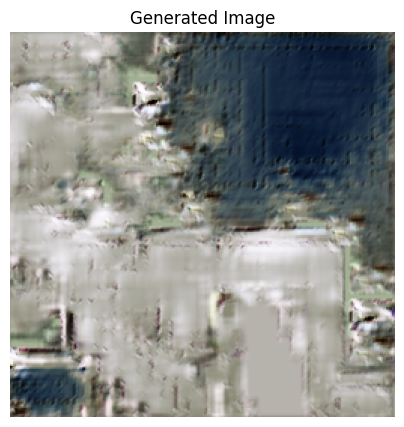

In [4]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# ================================================================================
# Dataset Paths and Transforms
# ================================================================================
base_path = '/kaggle/input/assignment5-dataset/Dataset'
train_path = os.path.join(base_path, 'train')
val_path   = os.path.join(base_path, 'val')
test_path  = os.path.join(base_path, 'test')

# Ensure all images are converted to RGB and resized to 256x256
transform = transforms.Compose([
    transforms.Lambda(lambda x: x.convert("RGB")),
    transforms.Resize((256, 256)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder(train_path, transform=transform)
val_dataset   = datasets.ImageFolder(val_path, transform=transform)
test_dataset  = datasets.ImageFolder(test_path, transform=transform)

batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print('Train samples:', len(train_dataset))
print('Validation samples:', len(val_dataset))
print('Test samples:', len(test_dataset))

# ================================================================================
# Hierarchical VAE (HVAE) Model Definition
# ================================================================================
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

class HVAEEncoder(nn.Module):
    def __init__(self, latent_dim1=64, latent_dim2=32):
        super(HVAEEncoder, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),   # 256 -> 128
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 128 -> 64
            nn.ReLU(),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 64 -> 32
            nn.ReLU(),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # 32 -> 16
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=4, stride=2, padding=1), # 16 -> 8
            nn.ReLU()
        )
        self.flatten = nn.Flatten()
        self.fc_size = 512 * 8 * 8

        self.fc_mu2 = nn.Linear(self.fc_size, latent_dim2)
        self.fc_logvar2 = nn.Linear(self.fc_size, latent_dim2)
        self.fc_mu1 = nn.Linear(self.fc_size + latent_dim2, latent_dim1)
        self.fc_logvar1 = nn.Linear(self.fc_size + latent_dim2, latent_dim1)

    def forward(self, x):
        h = self.conv(x)
        h_flat = self.flatten(h)
        mu2 = self.fc_mu2(h_flat)
        logvar2 = self.fc_logvar2(h_flat)
        z2 = reparameterize(mu2, logvar2)
        h_comb = torch.cat([h_flat, z2], dim=1)
        mu1 = self.fc_mu1(h_comb)
        logvar1 = self.fc_logvar1(h_comb)
        z1 = reparameterize(mu1, logvar1)
        return mu1, logvar1, z1, mu2, logvar2, z2

class HVAE_Decoder(nn.Module):
    def __init__(self, latent_dim1=64, latent_dim2=32):
        super(HVAE_Decoder, self).__init__()
        self.fc = nn.Linear(latent_dim1 + latent_dim2, 512 * 8 * 8)
        self.decoder_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),             # 8 -> 16
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),             # 16 -> 32
            nn.Conv2d(512, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),             # 32 -> 64
            nn.Conv2d(256, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),             # 64 -> 128
            nn.Conv2d(128, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Upsample(scale_factor=2, mode='nearest'),             # 128 -> 256
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid()  # Ensure output pixel values are in [0, 1]
        )

    def forward(self, z1, z2):
        z = torch.cat([z1, z2], dim=1)
        h = self.fc(z)
        h = h.view(-1, 512, 8, 8)
        x_recon = self.decoder_conv(h)
        return x_recon

class HierarchicalVAE(nn.Module):
    def __init__(self, latent_dim1=64, latent_dim2=32):
        super(HierarchicalVAE, self).__init__()
        self.encoder = HVAEEncoder(latent_dim1, latent_dim2)
        self.decoder = HVAE_Decoder(latent_dim1, latent_dim2)
        
    def forward(self, x):
        mu1, logvar1, z1, mu2, logvar2, z2 = self.encoder(x)
        x_recon = self.decoder(z1, z2)
        return x_recon, mu1, logvar1, mu2, logvar2

# ================================================================================
# Discriminator Definition (for Adversarial Loss)
# ================================================================================
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: 3 x 256 x 256
            nn.Conv2d(3, 64, kernel_size=4, stride=2, padding=1),  # 256 -> 128
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 128 -> 64
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 64 -> 32
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1), # 32 -> 16
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0),   # Output a single scalar per sample
            nn.Sigmoid()
        )
    def forward(self, x):
        out = self.main(x)
        # Average the output spatially to get one value per sample
        return out.view(x.size(0), -1).mean(dim=1, keepdim=True)

# ================================================================================
# Training Setup
# ================================================================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = HierarchicalVAE(latent_dim1=64, latent_dim2=32).to(device)
discriminator = Discriminator().to(device)

# Two optimizers: one for the generator (VAE) and one for the discriminator.
optimizer_G = optim.Adam(model.parameters(), lr=1e-3)
optimizer_D = optim.Adam(discriminator.parameters(), lr=1e-4)

# Define loss functions
bce_loss = nn.BCELoss()  # For adversarial loss

def recon_loss_fn(x_recon, x):
    return F.l1_loss(x_recon, x, reduction='mean')

# Weight factors for different loss components
lambda_KL = 1.0   # Weight for KL divergence loss
lambda_adv = 0.1  # Weight for adversarial loss

# ================================================================================
# Training Loop (VAE-GAN Hybrid)
# ================================================================================
num_epochs = 50
for epoch in range(num_epochs):
    model.train()
    discriminator.train()
    total_loss_G = 0.0
    total_loss_D = 0.0

    for data, _ in train_loader:
        data = data.to(device)
        batch_size = data.size(0)

        # ----- Train Discriminator -----
        discriminator.zero_grad()
        # Real images: label 1
        real_labels = torch.ones(batch_size, 1, device=device)
        output_real = discriminator(data)  # shape: [batch_size, 1]
        loss_D_real = bce_loss(output_real, real_labels)

        # Generate fake images using current VAE
        x_recon, mu1, logvar1, mu2, logvar2 = model(data)
        fake_labels = torch.zeros(batch_size, 1, device=device)
        # Detach fake images to avoid backprop through the generator
        output_fake = discriminator(x_recon.detach())
        loss_D_fake = bce_loss(output_fake, fake_labels)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()
        total_loss_D += loss_D.item()

        # ----- Train Generator (HVAE) -----
        model.zero_grad()
        # Forward pass: get reconstruction and latent parameters
        x_recon, mu1, logvar1, mu2, logvar2 = model(data)
        # Reconstruction loss (L1 mean loss)
        rec_loss = recon_loss_fn(x_recon, data)
        # KL divergence losses
        kl_z1 = -0.5 * torch.mean(1 + logvar1 - mu1.pow(2) - logvar1.exp())
        kl_z2 = -0.5 * torch.mean(1 + logvar2 - mu2.pow(2) - logvar2.exp())
        kl_loss = kl_z1 + kl_z2

        # Adversarial loss: try to fool the discriminator so that fake images are classified as real
        output_fake_for_G = discriminator(x_recon)
        adv_loss = bce_loss(output_fake_for_G, real_labels)

        loss_G = rec_loss + lambda_KL * kl_loss + lambda_adv * adv_loss
        loss_G.backward()
        optimizer_G.step()
        total_loss_G += loss_G.item()

    avg_loss_G = total_loss_G / len(train_loader)
    avg_loss_D = total_loss_D / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] Generator Loss: {avg_loss_G:.4f}, Discriminator Loss: {avg_loss_D:.4f}")

# ================================================================================
# Generate and Display an Image
# ================================================================================
model.eval()
with torch.no_grad():
    # Sample random latent vectors
    z1 = torch.randn(1, 64).to(device)
    z2 = torch.randn(1, 32).to(device)
    generated_img = model.decoder(z1, z2)

# Convert image tensor [1, 3, 256, 256] to a NumPy array for visualization.
img_np = generated_img[0].cpu().permute(1, 2, 0).numpy()

plt.figure(figsize=(5, 5))
plt.imshow(img_np)
plt.axis('off')
plt.title("Generated Image")
plt.show()


Number of training images found: 1470
Epoch [1/20]: Train Loss: 8381.3449 | Val Loss: 7015.5131
Epoch [2/20]: Train Loss: 6394.7214 | Val Loss: 5807.6752
Epoch [3/20]: Train Loss: 5499.6427 | Val Loss: 5256.5949
Epoch [4/20]: Train Loss: 4958.7366 | Val Loss: 4792.9500
Epoch [5/20]: Train Loss: 4595.9919 | Val Loss: 4632.4598
Epoch [6/20]: Train Loss: 4353.0484 | Val Loss: 4516.6364
Epoch [7/20]: Train Loss: 4120.3094 | Val Loss: 4417.1671
Epoch [8/20]: Train Loss: 3984.2804 | Val Loss: 4370.1792
Epoch [9/20]: Train Loss: 3752.5156 | Val Loss: 4324.3922
Epoch [10/20]: Train Loss: 3555.3962 | Val Loss: 4331.2656
Epoch [11/20]: Train Loss: 3381.4531 | Val Loss: 4357.4776
Epoch [12/20]: Train Loss: 3223.5208 | Val Loss: 4353.1539
Epoch [13/20]: Train Loss: 3059.0724 | Val Loss: 4366.8802
Epoch [14/20]: Train Loss: 2919.4253 | Val Loss: 4370.9335
Epoch [15/20]: Train Loss: 2875.4416 | Val Loss: 4462.5138
Epoch [16/20]: Train Loss: 2755.8171 | Val Loss: 4407.9770
Epoch [17/20]: Train Loss: 

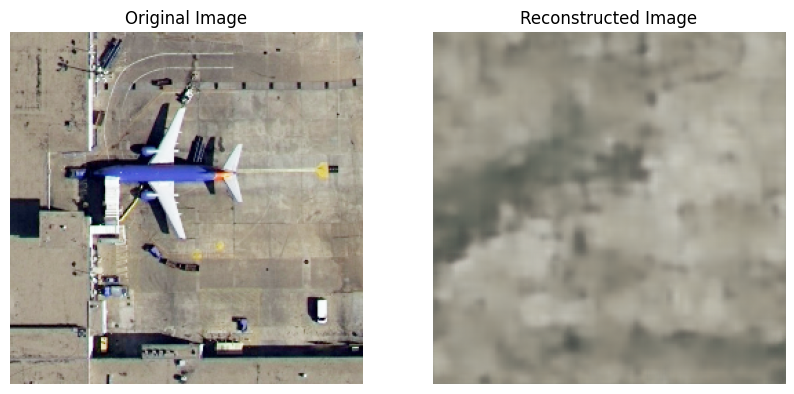

In [16]:
# Import necessary libraries
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.optim as optim

###############################################
# 1. Custom Dataset Class (Recursive Search)
###############################################
class UCMercedDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        """
        Args:
            root_dir (str): Root directory containing subfolders with images.
            transform (callable, optional): Transform to apply to the images.
        """
        self.root_dir = root_dir
        # Recursively search for .tif files in root_dir and any subdirectories.
        self.files = glob.glob(os.path.join(root_dir, '**', '*.tif'), recursive=True)
        self.transform = transform

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        img_path = self.files[idx]
        image = Image.open(img_path).convert('RGB')  # Force conversion to RGB
        if self.transform:
            image = self.transform(image)
        return image

# Define transforms for images: ensure they are 256x256 and converted to Tensor.
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    # Uncomment the following if you wish to normalize the images:
    # transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
])

###############################################
# 2. Create Datasets and DataLoaders
###############################################
# Set your dataset paths (update if necessary)
train_path = '/kaggle/input/assignment5-dataset/Dataset/train'
val_path   = '/kaggle/input/assignment5-dataset/Dataset/val'
test_path  = '/kaggle/input/assignment5-dataset/Dataset/test'

# Create datasets for each split.
train_dataset = UCMercedDataset(train_path, transform=transform)
val_dataset   = UCMercedDataset(val_path, transform=transform)
test_dataset  = UCMercedDataset(test_path, transform=transform)

# Debug: Print number of images found in the training dataset.
print("Number of training images found:", len(train_dataset))

# Create DataLoaders.
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

###############################################
# 3. Hierarchical VAE Model Definition
###############################################
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

class Encoder(nn.Module):
    def __init__(self, latent_dim1, latent_dim2):
        super(Encoder, self).__init__()
        # Input image size is 256x256 with 3 channels.
        self.conv1 = nn.Conv2d(3, 32, kernel_size=4, stride=2, padding=1)   # 256 -> 128
        self.conv2 = nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1)  # 128 -> 64
        self.conv3 = nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1) # 64 -> 32
        self.conv4 = nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1) # 32 -> 16
        
        # After conv layers, the feature map is 16x16.
        self.flat_dim = 256 * 16 * 16
        
        # Fully-connected layers for two latent spaces.
        # Global latent representation:
        self.fc_mu1    = nn.Linear(self.flat_dim, latent_dim1)
        self.fc_logvar1 = nn.Linear(self.flat_dim, latent_dim1)
        # Local latent representation:
        self.fc_mu2    = nn.Linear(self.flat_dim, latent_dim2)
        self.fc_logvar2 = nn.Linear(self.flat_dim, latent_dim2)

    def forward(self, x):
        h = F.relu(self.conv1(x))
        h = F.relu(self.conv2(h))
        h = F.relu(self.conv3(h))
        h = F.relu(self.conv4(h))
        h = h.view(x.size(0), -1)  # flatten the output

        mu1 = self.fc_mu1(h)
        logvar1 = self.fc_logvar1(h)
        mu2 = self.fc_mu2(h)
        logvar2 = self.fc_logvar2(h)
        return mu1, logvar1, mu2, logvar2

class HierarchicalVAE(nn.Module):
    def __init__(self, latent_dim1=64, latent_dim2=32):
        super(HierarchicalVAE, self).__init__()
        self.encoder = Encoder(latent_dim1, latent_dim2)
        # Combine latent dimensions.
        combined_latent_dim = latent_dim1 + latent_dim2
        
        # Project the combined latent space into the flattened feature space.
        self.fc_decode = nn.Linear(combined_latent_dim, 256 * 16 * 16)
        
        # Decoder: four deconvolution layers to upscale from 16x16 back to 256x256.
        self.deconv1 = nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1) # 16 -> 32
        self.deconv2 = nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1)  # 32 -> 64
        self.deconv3 = nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1)   # 64 -> 128
        self.deconv4 = nn.ConvTranspose2d(32, 3, kernel_size=4, stride=2, padding=1)    # 128 -> 256

    def forward(self, x):
        # Encode input.
        mu1, logvar1, mu2, logvar2 = self.encoder(x)
        z1 = reparameterize(mu1, logvar1)
        z2 = reparameterize(mu2, logvar2)
        # Combine latent variables
        z = torch.cat([z1, z2], dim=1)
        # Decode combined latent code.
        h = F.relu(self.fc_decode(z))
        h = h.view(x.size(0), 256, 16, 16)  # reshape into feature maps
        h = F.relu(self.deconv1(h))
        h = F.relu(self.deconv2(h))
        h = F.relu(self.deconv3(h))
        # Use sigmoid activation to get output in [0,1]
        reconstruction = torch.sigmoid(self.deconv4(h))
        return reconstruction, mu1, logvar1, mu2, logvar2

def loss_function(recon_x, x, mu1, logvar1, mu2, logvar2):
    # Mean Squared Error reconstruction loss; adjust "reduction" as needed.
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    # KL divergence for both latent distributions.
    kld1 = -0.5 * torch.sum(1 + logvar1 - mu1.pow(2) - logvar1.exp())
    kld2 = -0.5 * torch.sum(1 + logvar2 - mu2.pow(2) - logvar2.exp())
    return recon_loss + kld1 + kld2

###############################################
# 4. Training the Hierarchical VAE
###############################################
# Set device to GPU if available.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Instantiate the model with chosen latent dimensions.
model = HierarchicalVAE(latent_dim1=64, latent_dim2=32).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 20  # Adjust epochs based on your needs

for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for batch in train_loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        recon_batch, mu1, logvar1, mu2, logvar2 = model(batch)
        loss = loss_function(recon_batch, batch, mu1, logvar1, mu2, logvar2)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    avg_train_loss = train_loss / len(train_dataset)
    
    # Validation step.
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in val_loader:
            batch = batch.to(device)
            recon_batch, mu1, logvar1, mu2, logvar2 = model(batch)
            loss = loss_function(recon_batch, batch, mu1, logvar1, mu2, logvar2)
            val_loss += loss.item()
    avg_val_loss = val_loss / len(val_dataset)
    
    print(f"Epoch [{epoch+1}/{num_epochs}]: Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

###############################################
# 5. Testing & Visualizing a Reconstructed Image
###############################################
# Let's pick one example image from the test dataset.
model.eval()
with torch.no_grad():
    sample_image = test_dataset[0]       # Pick the first image
    sample_tensor = sample_image.unsqueeze(0).to(device)  # Add a batch dimension
    recon_image, _, _, _, _ = model(sample_tensor)

# Convert tensors to CPU and numpy arrays for visualization.
sample_np = sample_image.permute(1, 2, 0).cpu().numpy()
recon_np = recon_image.squeeze().permute(1, 2, 0).cpu().numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_np)
plt.title("Original Image")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(recon_np)
plt.title("Reconstructed Image")
plt.axis('off')
plt.show()
